# Model Comparison — RF vs Logistic Regression

Compares Random Forest and L2-penalised Logistic Regression for predicting
berm **condition** (Intact) and **vegetation response** (Effective).

**Workflow:**
1. Define predictor scenarios (geomorphology, soil, length, all combined)
2. Baseline: fit RF + Logistic across all scenarios (CV AUC comparison)
3. Feature selection via RF drop-column importance (ΔAUC when each predictor removed)
4. Refit both models on selected features (ΔAUC ≥ 0) and compare
5. Feature importance: RF permutation importance + Logistic |coefficients|

Loads `../data/merged.csv` produced by `data processing - condition vegetation.ipynb`.


In [1]:
# ── 1. Imports ─────────────────────────────────────────────────────────────
import sys as _sys
_sys.path.insert(0, '../src')
from constants import (
    INTACT_COL, DEGRADED_COL,
    BREACH_COL, FLANK_COL,
    fail_order, fail_colors,
    LF_COLORS, lf_order,
    TEXTURE_COLORS, texture_order,
    LENGTH_COLORS, length_order,
    MODEL_CLR_CONDITION, MODEL_CLR_VEGRESPONSE, MODEL_CLR_CHANCE,
)
from analysis import (
    fit_rf_binary, _unique_preserve, _coerce_binary,
    PRETTY_LABELS, _clean_predictor_name,
    analyze_outcome, pairwise_by_group,
)
from registry import register_outcomes_figure, register_failure_mechanisms_figure

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)

from scipy.stats import fisher_exact
from sklearn.model_selection import StratifiedKFold, train_test_split, cross_validate
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score
from sklearn.inspection import permutation_importance
from IPython.display import display

pd.set_option('display.max_columns', 50)
print('Imports OK')

# ── Adjustable font size for all figures in this notebook ─────────
_FS = 13
_FS_SUP = _FS + 2

Imports OK


In [2]:
# ── 2. Load data ──────────────────────────────────────────────────────────
data = pd.read_csv('../data/merged.csv')
df = data.loc[data['Structure_'].isna()].copy() if 'Structure_' in data.columns else data.copy()
print(f'Loaded {len(data):,} rows → df: {len(df):,} rows (after dropping artificial structures)')

Loaded 775 rows → df: 743 rows (after dropping artificial structures)


In [3]:
# ── 3. Predictor scenario definitions ─────────────────────────────────────
treat_as = {
    'Shape_Leng': 'numeric',
    'High_Clay':  'categorical',
}

_geo_preds   = ['Landform', 'slope_200', 'FA_30_max',  'FA_60_max']
_soil_preds  = ['Texture', 'Soil_Development', 'TypicalProfile',
                'profile_depth_cm', 'b_horizon_depth_cm', 'restriction_depth_cm']
_len_preds   = ['Shape_Leng', 'Berm_Length_Class']
_all_preds  = _unique_preserve(_geo_preds + _soil_preds + _len_preds)

scenario_predictors = {
    'landscape_geomorphology_only': _geo_preds,
    'soil_only':                    _soil_preds,
    'shape_length_only':            _len_preds,
    'all_predictors':               _all_preds,
}

_targets = ['Intact', 'Effective']
print(f'All predictors: {_all_preds}')
print(f'Targets: {_targets}')

All predictors: ['Landform', 'slope_200', 'FA_30_max', 'FA_60_max', 'Texture', 'Soil_Development', 'TypicalProfile', 'profile_depth_cm', 'b_horizon_depth_cm', 'restriction_depth_cm', 'Shape_Leng', 'Berm_Length_Class']
Targets: ['Intact', 'Effective']


In [ ]:
# ── 4. Unified model pipeline builder ─────────────────────────────────────

def _build_pipeline(model_type, predictors, treat_as_map=None, source_df=None):
    """Build a sklearn Pipeline for either RF or Logistic regression.

    Parameters
    ----------
    model_type : {'RF', 'Logistic'}
    predictors : list[str]
    treat_as_map : dict, optional
    source_df : DataFrame, optional – used only to infer dtypes (defaults to ``df``)
    """
    treat_as_map = treat_as_map or {}
    _df = source_df if source_df is not None else df
    cat_cols, num_cols = [], []
    for c in predictors:
        ta = treat_as_map.get(c)
        if ta == 'categorical':
            cat_cols.append(c)
        elif ta == 'numeric':
            num_cols.append(c)
        elif _df[c].dtype == object or pd.api.types.is_string_dtype(_df[c]) or str(_df[c].dtype).startswith('category'):
            cat_cols.append(c)
        else:
            num_cols.append(c)

    pre = ColumnTransformer(
        transformers=[
            ('num', Pipeline([
                ('impute', SimpleImputer(strategy='median')),
                ('scale', StandardScaler()),
            ]), num_cols),
            ('cat', Pipeline([
                ('impute', SimpleImputer(strategy='most_frequent')),
                ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
            ]), cat_cols),
        ],
        remainder='drop',
    )

    if model_type == 'RF':
        clf = RandomForestClassifier(
            n_estimators=300, min_samples_leaf=2,
            class_weight='balanced', random_state=0, n_jobs=-1,
        )
    elif model_type == 'Logistic':
        clf = LogisticRegression(
            C=1.0, penalty='l2', max_iter=2000,
            class_weight='balanced', solver='lbfgs', random_state=0,
        )
    else:
        raise ValueError(f'Unknown model_type: {model_type}')

    return Pipeline([('pre', pre), ('clf', clf)])


def _fit_and_evaluate(model_type, predictors, target, treat_as_map=None,
                      test_size=0.25, random_state=0, source_df=None):
    """
    Fit a pipeline, return (pipeline, metrics_dict, pi_series).

    Parameters
    ----------
    source_df : DataFrame, optional – defaults to module-level ``df``.
    """
    treat_as_map = treat_as_map or {}
    _df = source_df if source_df is not None else df
    sub = _df[predictors + [target]].copy()
    sub[target] = _coerce_binary(sub[target])
    sub = sub.dropna(subset=[target])

    X = sub[predictors]
    yv = sub[target].astype(int)

    pipe = _build_pipeline(model_type, predictors, treat_as_map, source_df=_df)

    X_tr, X_te, y_tr, y_te = train_test_split(
        X, yv, test_size=test_size, stratify=yv, random_state=random_state)
    pipe.fit(X_tr, y_tr)

    holdout_auc = roc_auc_score(y_te, pipe.predict_proba(X_te)[:, 1])

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=random_state)
    cv_scores = cross_validate(
        pipe, X, yv, cv=cv,
        scoring={'auc': 'roc_auc', 'bal_acc': 'balanced_accuracy', 'f1': 'f1'},
        n_jobs=-1, return_train_score=False,
    )
    cv_summary = {
        k.replace('test_', ''): (float(np.mean(v)), float(np.std(v)))
        for k, v in cv_scores.items() if k.startswith('test_')
    }

    pi = permutation_importance(
        pipe, X_te, y_te, scoring='roc_auc',
        n_repeats=30, random_state=random_state, n_jobs=-1,
    )
    pi_series = pd.Series(pi.importances_mean, index=predictors).sort_values(ascending=False)

    metrics = {
        'cv': cv_summary,
        'holdout': {'auc': float(holdout_auc)},
        'n': int(len(X)),
    }
    return pipe, metrics, pi_series


print('Pipeline builder & evaluator defined')

Pipeline builder & evaluator defined


## Baseline: all scenarios × both models

In [5]:
# ── 5. Baseline scenario sweep ────────────────────────────────────────────
_model_types = ['RF', 'Logistic']
baseline_rows = []
baseline_results = {}  # (scenario, model_type, target) → (pipe, metrics, pi)

for _scenario, _preds in scenario_predictors.items():
    _preds_run = [p for p in _preds if p in df.columns]
    if not _preds_run:
        print(f'Skipping {_scenario}: no columns found')
        continue
    for _mt in _model_types:
        for _tgt in _targets:
            try:
                _pipe, _met, _pi = _fit_and_evaluate(
                    _mt, _preds_run, _tgt, treat_as_map=treat_as)
            except Exception as _e:
                print(f'  SKIP {_scenario}/{_mt}/{_tgt}: {_e}')
                continue

            baseline_results[(_scenario, _mt, _tgt)] = (_pipe, _met, _pi)
            baseline_rows.append({
                'scenario':    _scenario,
                'model':       _mt,
                'target':      _tgt,
                'cv_auc_mean': _met['cv']['auc'][0],
                'cv_auc_sd':   _met['cv']['auc'][1],
                'holdout_auc': _met['holdout']['auc'],
                'n':           _met['n'],
            })

baseline_df = pd.DataFrame(baseline_rows)
print(f'\nDone — {len(baseline_rows)} fits')
display(baseline_df.sort_values(['target', 'scenario', 'model']))


Done — 16 fits


,scenario,model,target,cv_auc_mean,cv_auc_sd,holdout_auc,n
15,all_predictors,Logistic,Effective,0.638329,0.036104,0.667208,743
13,all_predictors,RF,Effective,0.652740,0.028939,0.638219,743
3,landscape_geomorphology_only,Logistic,Effective,0.626069,0.042994,0.658279,743
1,landscape_geomorphology_only,RF,Effective,0.622539,0.036630,0.653293,743
11,shape_length_only,Logistic,Effective,0.516239,0.025577,0.544527,743
9,shape_length_only,RF,Effective,0.559742,0.033407,0.499826,743
7,soil_only,Logistic,Effective,0.579244,0.021121,0.641756,743
5,soil_only,RF,Effective,0.570033,0.029497,0.626797,743
14,all_predictors,Logistic,Intact,0.671094,0.032286,0.701804,743
12,all_predictors,RF,Intact,0.732288,0.016633,0.756054,743


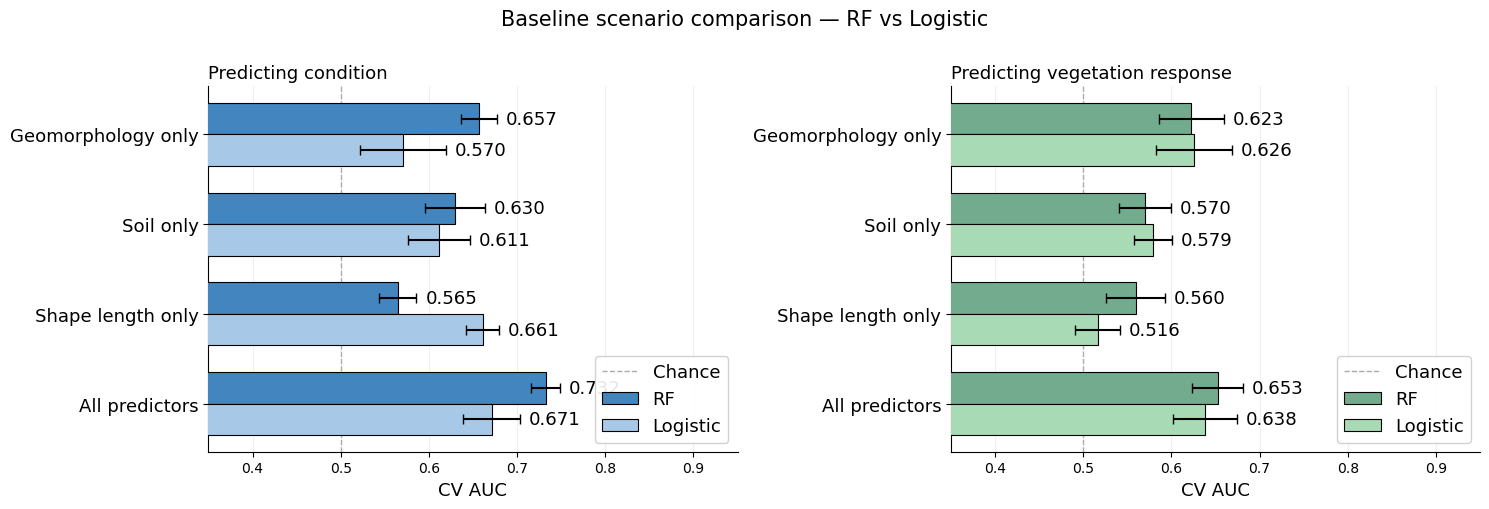

Baseline comparison plotted


In [6]:
# ── 6. Grouped horizontal bar chart: scenario × model × target ────────────
_key_order = ['landscape_geomorphology_only', 'soil_only',
              'shape_length_only', 'all_predictors']
_label_map = {
    'landscape_geomorphology_only': 'Geomorphology only',
    'soil_only':                    'Soil only',
    'shape_length_only':            'Shape length only',
    'all_predictors':               'All predictors',
}

fig1, axes = plt.subplots(1, 2, figsize=(15, 5), sharex=True)
_y_pos = np.arange(len(_key_order))
_w = 0.35

_clr_rf = {'Intact': MODEL_CLR_CONDITION, 'Effective': MODEL_CLR_VEGRESPONSE}
_clr_lr = {'Intact': '#a8c8e8', 'Effective': '#a8dbb5'}  # lighter tints for Logistic

for ax_idx, _tgt in enumerate(_targets):
    ax = axes[ax_idx]
    _sub = baseline_df[baseline_df['target'] == _tgt].copy()

    _rf_rows = _sub[_sub['model'] == 'RF'].set_index('scenario').reindex(_key_order)
    _lr_rows = _sub[_sub['model'] == 'Logistic'].set_index('scenario').reindex(_key_order)

    ax.barh(_y_pos - _w/2, _rf_rows['cv_auc_mean'].values, _w,
            xerr=_rf_rows['cv_auc_sd'].values,
            color=_clr_rf[_tgt], edgecolor='black', lw=0.8, capsize=3.5,
            label='RF', zorder=3)
    ax.barh(_y_pos + _w/2, _lr_rows['cv_auc_mean'].values, _w,
            xerr=_lr_rows['cv_auc_sd'].values,
            color=_clr_lr[_tgt], edgecolor='black', lw=0.8, capsize=3.5,
            label='Logistic', zorder=3)

    # Value labels to the right of each bar
    for i in range(len(_key_order)):
        ax.text(_rf_rows['cv_auc_mean'].values[i] + _rf_rows['cv_auc_sd'].values[i] + 0.01,
                i - _w/2, f'{_rf_rows["cv_auc_mean"].values[i]:.3f}',
                ha='left', va='center', fontsize=_FS)
        ax.text(_lr_rows['cv_auc_mean'].values[i] + _lr_rows['cv_auc_sd'].values[i] + 0.01,
                i + _w/2, f'{_lr_rows["cv_auc_mean"].values[i]:.3f}',
                ha='left', va='center', fontsize=_FS)

    ax.axvline(0.5, color=MODEL_CLR_CHANCE, ls='--', lw=1, label='Chance', zorder=0)
    ax.set_yticks(_y_pos)
    ax.set_yticklabels([_label_map[s] for s in _key_order], fontsize=_FS)
    ax.invert_yaxis()
    ax.set_xlim(0.35, 0.95)
    ax.set_xlabel('CV AUC', fontsize=_FS)
    ax.set_title(f'Predicting {"condition" if _tgt == "Intact" else "vegetation response"}',
                 fontsize=_FS, fontweight='normal', loc='left')
    ax.legend(fontsize=_FS, loc='lower right', framealpha=0.9)
    ax.spines[['top', 'right']].set_visible(False)
    ax.grid(axis='x', alpha=0.2)

fig1.suptitle('Baseline scenario comparison — RF vs Logistic',
              fontsize=_FS_SUP, fontweight='normal', y=1.01)
plt.tight_layout()
plt.show()
print('Baseline comparison plotted')

## Feature selection — RF drop-column importance

For each predictor, refit RF without it and measure the change in CV AUC.
Positive ΔAUC = removing the predictor **hurts** (useful predictor).
Negative ΔAUC = removing the predictor **helps** (drop it).
Predictors with ΔAUC < 0 are dropped before refitting both models.

Computing drop-column importances (2 × 12 RF refits) …

  Drop-column importance for Intact
  Baseline CV AUC: 0.732
  Selected (12 / 12): ['Landform', 'slope_200', 'FA_30_max', 'FA_60_max', 'Texture', 'Soil_Development', 'TypicalProfile', 'profile_depth_cm', 'b_horizon_depth_cm', 'restriction_depth_cm', 'Shape_Leng', 'Berm_Length_Class']



,ΔAUC
Shape_Leng,0.0286
FA_30_max,0.0177
slope_200,0.0167
TypicalProfile,0.0159
restriction_depth_cm,0.0063
Berm_Length_Class,0.0050
profile_depth_cm,0.0034
Soil_Development,0.0025
FA_60_max,0.0020
Texture,0.0017



  Drop-column importance for Effective
  Baseline CV AUC: 0.653
  Selected (6 / 12): ['Landform', 'slope_200', 'Texture', 'profile_depth_cm', 'b_horizon_depth_cm', 'Shape_Leng']
  Dropped (ΔAUC < 0): ['FA_30_max', 'FA_60_max', 'Soil_Development', 'TypicalProfile', 'restriction_depth_cm', 'Berm_Length_Class']



,ΔAUC
slope_200,0.0479
Shape_Leng,0.0109
Texture,0.0060
b_horizon_depth_cm,0.0051
profile_depth_cm,0.0048
Landform,0.0039
Soil_Development,-0.0003
FA_60_max,-0.0004
TypicalProfile,-0.0006
restriction_depth_cm,-0.0007


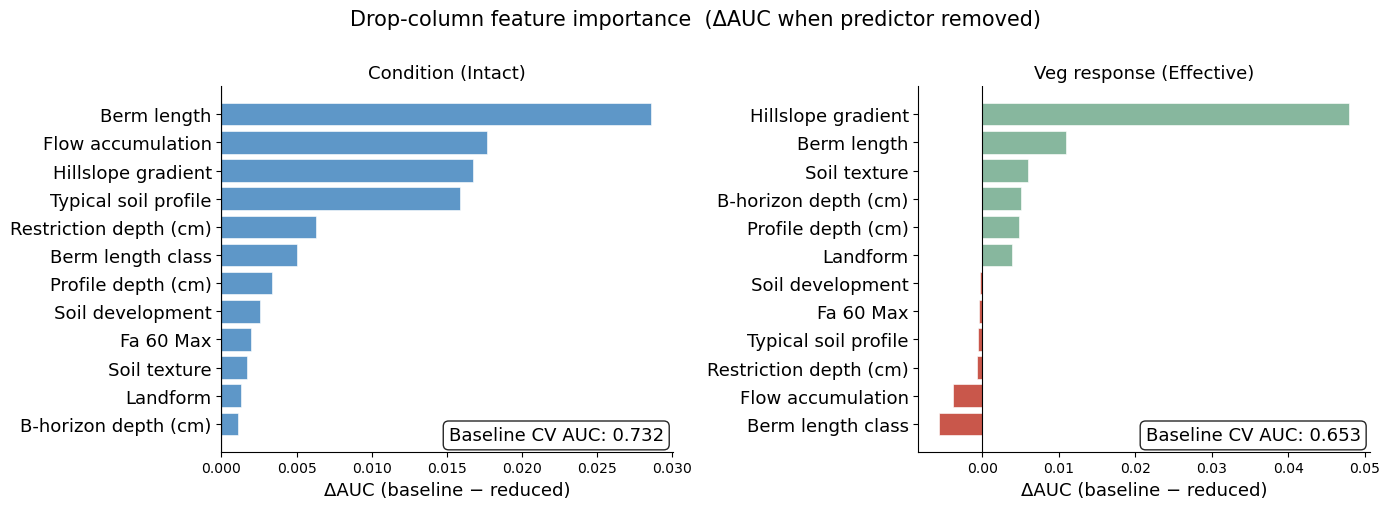

In [7]:
# ── 7. Drop-column feature importance (RF) ────────────────────────────────

def _drop_col_importance(predictors, target, treat_as_map=None, source_df=None):
    """Return a Series of ΔAUC when each predictor is removed from RF."""
    treat_as_map = treat_as_map or {}
    _df = source_df if source_df is not None else df
    # Baseline AUC with all predictors
    _, _base_met, _ = _fit_and_evaluate(
        'RF', predictors, target, treat_as_map=treat_as_map, source_df=_df)
    _base_auc = _base_met['cv']['auc'][0]
    rows = {}
    for drop_p in predictors:
        reduced = [p for p in predictors if p != drop_p]
        try:
            _, _m, _ = _fit_and_evaluate(
                'RF', reduced, target, treat_as_map=treat_as_map, source_df=_df)
            reduced_auc = _m['cv']['auc'][0]
        except Exception:
            reduced_auc = np.nan
        rows[drop_p] = _base_auc - reduced_auc   # positive = useful predictor
    return pd.Series(rows).sort_values(ascending=False), _base_auc


print(f'Computing drop-column importances (2 × {len(_all_preds)} RF refits) …')
dc_results = {}      # target → {'importance': Series, 'baseline_auc': float,
                      #            'selected_predictors': list, 'dropped': list}
for _tgt in _targets:
    print(f'\n{"="*60}')
    print(f'  Drop-column importance for {_tgt}')
    print(f'{"="*60}')
    _dc, _base = _drop_col_importance(_all_preds, _tgt, treat_as_map=treat_as)
    _selected = [p for p in _all_preds if _dc[p] >= 0]
    _dropped  = [p for p in _all_preds if _dc[p] < 0]
    dc_results[_tgt] = {
        'importance': _dc,
        'baseline_auc': _base,
        'selected_predictors': _selected,
        'dropped': _dropped,
    }
    print(f'  Baseline CV AUC: {_base:.3f}')
    print(f'  Selected ({len(_selected)} / {len(_all_preds)}): {_selected}')
    if _dropped:
        print(f'  Dropped (ΔAUC < 0): {_dropped}')
    print()
    display(_dc.rename('ΔAUC').to_frame().style.format('{:.4f}'))

# ── Plot ──────────────────────────────────────────────────────────────────
fig_dc, (ax_dc1, ax_dc2) = plt.subplots(1, 2, figsize=(14, 5))
fig_dc.suptitle('Drop-column feature importance  (ΔAUC when predictor removed)',
                fontsize=_FS_SUP, fontweight='normal', y=1.01)

for ax, _tgt, title, color in [
    (ax_dc1, 'Intact',    'Condition (Intact)',       MODEL_CLR_CONDITION),
    (ax_dc2, 'Effective', 'Veg response (Effective)', MODEL_CLR_VEGRESPONSE),
]:
    _dc = dc_results[_tgt]['importance']
    _base = dc_results[_tgt]['baseline_auc']
    _dc_pretty = _dc.rename(index=lambda x: _clean_predictor_name(x))
    y = np.arange(len(_dc_pretty))
    bar_colors = [color if v >= 0 else '#c0392b' for v in _dc_pretty.values]
    ax.barh(y, _dc_pretty.values, color=bar_colors, alpha=0.85,
            edgecolor='white', linewidth=0.5)
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_yticks(y)
    ax.set_yticklabels(_dc_pretty.index, fontsize=_FS)
    ax.invert_yaxis()
    ax.set_xlabel('ΔAUC (baseline − reduced)', fontsize=_FS)
    ax.set_title(title, fontsize=_FS, fontweight='normal')
    ax.spines[['top', 'right']].set_visible(False)
    ax.text(0.98, 0.02, f'Baseline CV AUC: {_base:.3f}',
            transform=ax.transAxes, ha='right', va='bottom', fontsize=_FS,
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.85))

plt.tight_layout()
plt.show()

In [8]:
# ── 8. Feature selection summary table ────────────────────────────────────
_sel_rows = []
for _p in _all_preds:
    _row = {'Predictor': _clean_predictor_name(_p)}
    for _tgt in _targets:
        _dc_val = dc_results[_tgt]['importance'][_p]
        _row[f'ΔAUC ({_tgt})'] = f'{_dc_val:+.4f}'
        _row[f'Keep ({_tgt})'] = '✓' if _dc_val >= 0 else '✗'
    _sel_rows.append(_row)

_sel_table = pd.DataFrame(_sel_rows)
display(_sel_table)

# Save
os.makedirs('../data/summary', exist_ok=True)
_sel_table.to_csv('../data/summary/dropcol_feature_selection.csv', index=False)
print('Saved: ../data/summary/dropcol_feature_selection.csv')

,Predictor,ΔAUC (Intact),Keep (Intact),ΔAUC (Effective),Keep (Effective)
0,Landform,+0.0013,✓,+0.0039,✓
1,Hillslope gradient,+0.0167,✓,+0.0479,✓
2,Flow accumulation,+0.0177,✓,-0.0038,✗
3,Fa 60 Max,+0.0020,✓,-0.0004,✗
4,Soil texture,+0.0017,✓,+0.0060,✓
5,Soil development,+0.0025,✓,-0.0003,✗
6,Typical soil profile,+0.0159,✓,-0.0006,✗
7,Profile depth (cm),+0.0034,✓,+0.0048,✓
8,B-horizon depth (cm),+0.0011,✓,+0.0051,✓
9,Restriction depth (cm),+0.0063,✓,-0.0007,✗


Saved: ../data/summary/dropcol_feature_selection.csv


## Refit on drop-column selected features

In [9]:
# ── 9. Refit RF + Logistic on drop-column selected features ───────────────
_refit_rows = []
refit_results = {}  # (model_type, target) → (pipe, metrics, pi)

for _tgt in _targets:
    _sel_preds = dc_results[_tgt]['selected_predictors']
    for _mt in _model_types:
        print(f'\nRefitting {_mt} for {_tgt} with {len(_sel_preds)} selected predictors...')
        _pipe, _met, _pi = _fit_and_evaluate(
            _mt, _sel_preds, _tgt, treat_as_map=treat_as)
        refit_results[(_mt, _tgt)] = (_pipe, _met, _pi)

        # Before (all_predictors) metrics
        _before_key = ('all_predictors', _mt, _tgt)
        if _before_key in baseline_results:
            _before_auc = baseline_results[_before_key][1]['cv']['auc'][0]
            _before_sd  = baseline_results[_before_key][1]['cv']['auc'][1]
        else:
            _before_auc, _before_sd = np.nan, np.nan

        _after_auc = _met['cv']['auc'][0]
        _after_sd  = _met['cv']['auc'][1]

        _refit_rows.append({
            'model':       _mt,
            'target':      _tgt,
            'n_pred_all':  len(_all_preds),
            'n_pred_sel':  len(_sel_preds),
            'auc_before':  _before_auc,
            'sd_before':   _before_sd,
            'auc_after':   _after_auc,
            'sd_after':    _after_sd,
            'delta_auc':   _after_auc - _before_auc,
        })
        print(f'  AUC: {_before_auc:.3f} → {_after_auc:.3f}  (Δ {_after_auc - _before_auc:+.3f})')

_refit_df = pd.DataFrame(_refit_rows)
display(_refit_df)


Refitting RF for Intact with 12 selected predictors...
  AUC: 0.732 → 0.732  (Δ +0.000)

Refitting Logistic for Intact with 12 selected predictors...
  AUC: 0.671 → 0.671  (Δ +0.000)

Refitting RF for Effective with 6 selected predictors...
  AUC: 0.653 → 0.651  (Δ -0.002)

Refitting Logistic for Effective with 6 selected predictors...
  AUC: 0.638 → 0.635  (Δ -0.003)


,model,target,n_pred_all,n_pred_sel,auc_before,sd_before,auc_after,sd_after,delta_auc
0,RF,Intact,12,12,0.732288,0.016633,0.732288,0.016633,0.000000
1,Logistic,Intact,12,12,0.671094,0.032286,0.671094,0.032286,0.000000
2,RF,Effective,12,6,0.652740,0.028939,0.650558,0.025500,-0.002181
3,Logistic,Effective,12,6,0.638329,0.036104,0.635411,0.044982,-0.002918


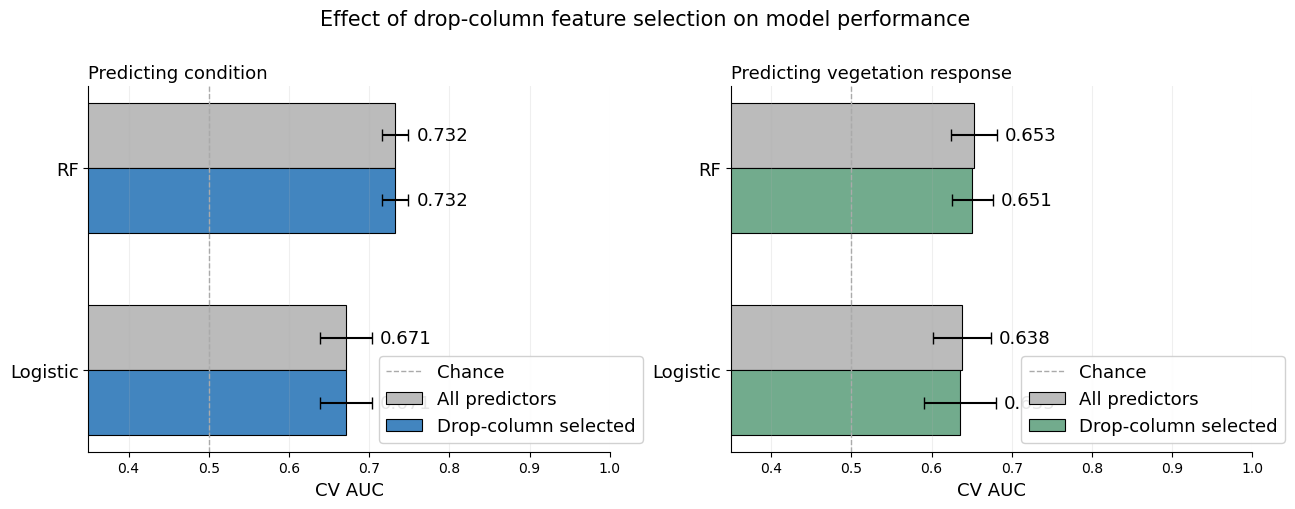

In [10]:
# ── 10. Before vs After feature selection bar chart ────────────────────────
fig2, axes2 = plt.subplots(1, 2, figsize=(13, 5), sharex=True)

for ax_idx, _tgt in enumerate(_targets):
    ax = axes2[ax_idx]
    _sub = _refit_df[_refit_df['target'] == _tgt]
    _y = np.arange(len(_model_types))
    _w = 0.32

    _clr_before = '#bbbbbb'
    _clr_after  = MODEL_CLR_CONDITION if _tgt == 'Intact' else MODEL_CLR_VEGRESPONSE

    for i, _mt in enumerate(_model_types):
        _r = _sub[_sub['model'] == _mt].iloc[0]
        ax.barh(i - _w/2, _r['auc_before'], _w, xerr=_r['sd_before'],
                color=_clr_before, edgecolor='black', lw=0.8, capsize=4,
                label='All predictors' if i == 0 else '')
        ax.barh(i + _w/2, _r['auc_after'], _w, xerr=_r['sd_after'],
                color=_clr_after, edgecolor='black', lw=0.8, capsize=4,
                label='Drop-column selected' if i == 0 else '')
        # value labels
        ax.text(_r['auc_before'] + _r['sd_before'] + 0.01, i - _w/2,
                f'{_r["auc_before"]:.3f}', ha='left', va='center', fontsize=_FS)
        ax.text(_r['auc_after'] + _r['sd_after'] + 0.01, i + _w/2,
                f'{_r["auc_after"]:.3f}', ha='left', va='center', fontsize=_FS)

    ax.axvline(0.5, color=MODEL_CLR_CHANCE, ls='--', lw=1, label='Chance')
    ax.set_yticks(_y)
    ax.set_yticklabels(_model_types, fontsize=_FS)
    ax.invert_yaxis()
    ax.set_xlabel('CV AUC', fontsize=_FS)
    ax.set_xlim(0.35, 1)
    ax.set_title(f'Predicting {"condition" if _tgt == "Intact" else "vegetation response"}',
                 fontsize=_FS, fontweight='normal', loc='left')
    ax.legend(fontsize=_FS, loc='lower right', bbox_to_anchor=(1.08, 0.0), framealpha=0.9)
    ax.spines[['top', 'right']].set_visible(False)
    ax.grid(axis='x', alpha=0.2)

fig2.suptitle('Effect of drop-column feature selection on model performance',
              fontsize=_FS_SUP, fontweight='normal', y=1.01)
plt.tight_layout()
plt.show()


## Feature importance — RF permutation vs Logistic coefficients

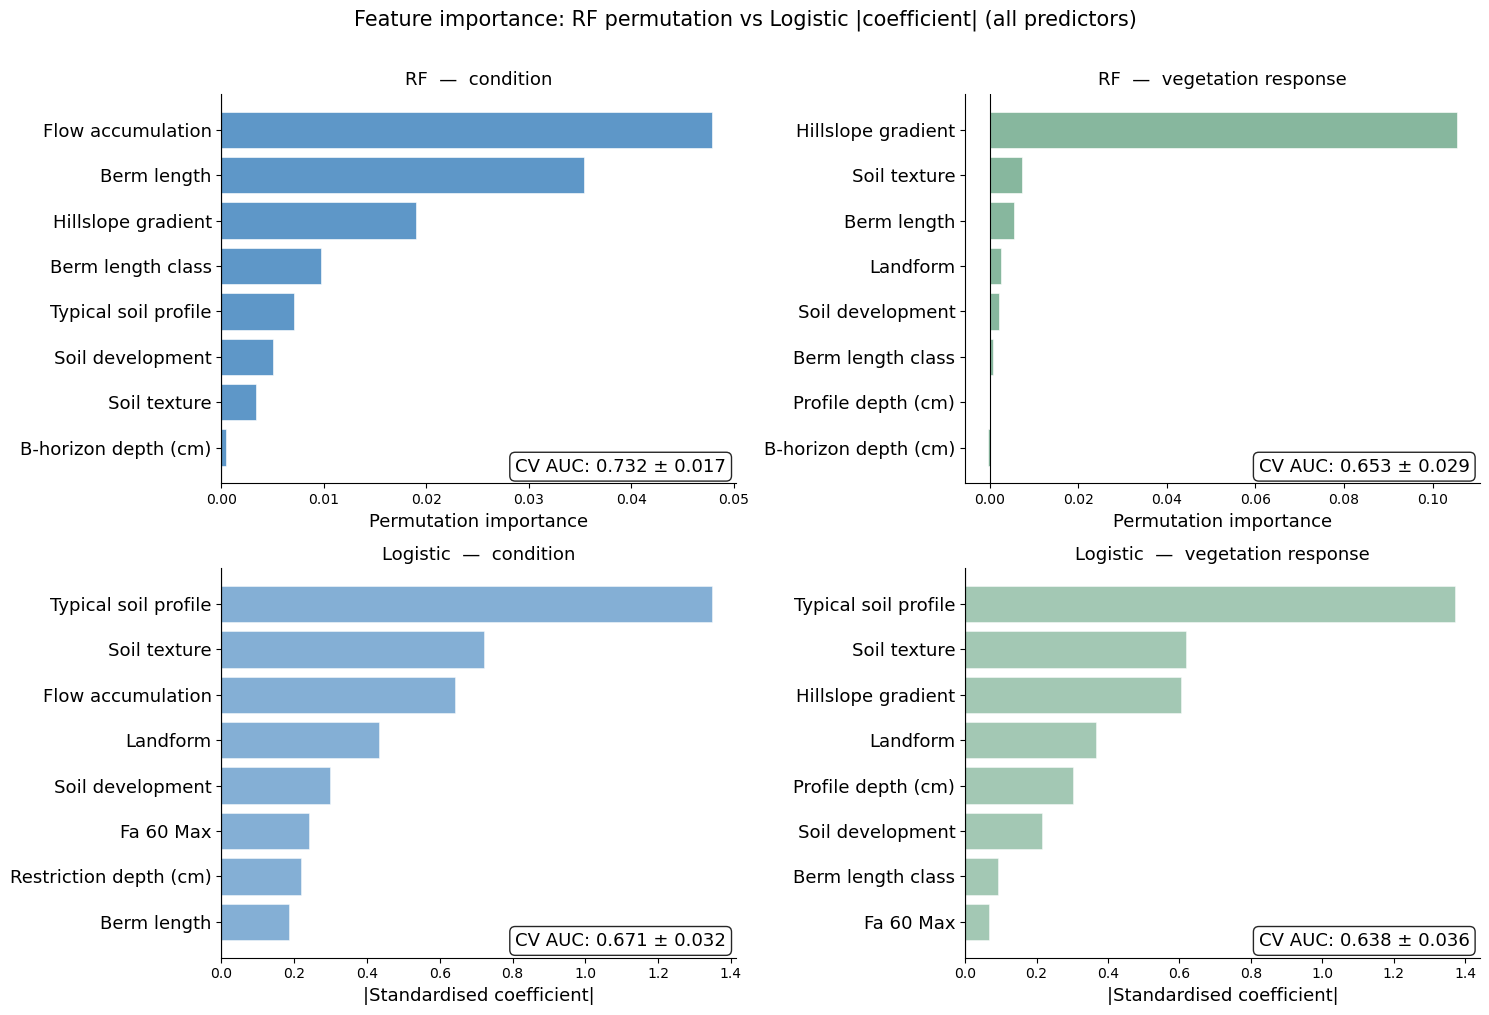

In [11]:
# ── 11. Feature importance comparison ─────────────────────────────────────

def _logistic_coef_importance(pipe, predictors, treat_as_map=None, source_df=None):
    """
    Extract absolute logistic coefficients from a fitted pipeline and
    aggregate back to original predictor level (max |coef| per predictor).
    """
    treat_as_map = treat_as_map or {}
    _df = source_df if source_df is not None else df
    coefs = pipe.named_steps['clf'].coef_.ravel()
    pre = pipe.named_steps['pre']

    # Rebuild encoded col → original predictor map
    cat_cols, num_cols = [], []
    for c in predictors:
        ta = treat_as_map.get(c)
        if ta == 'categorical':
            cat_cols.append(c)
        elif ta == 'numeric':
            num_cols.append(c)
        elif _df[c].dtype == object or pd.api.types.is_string_dtype(_df[c]) or str(_df[c].dtype).startswith('category'):
            cat_cols.append(c)
        else:
            num_cols.append(c)

    _agg = {}
    idx = 0
    for c in num_cols:
        _agg[c] = abs(coefs[idx])
        idx += 1
    ohe = pre.named_transformers_['cat'].named_steps['onehot']
    for name in ohe.get_feature_names_out(cat_cols):
        _orig = next(c for c in cat_cols if name.startswith(c + '_'))
        _agg[_orig] = max(_agg.get(_orig, 0), abs(coefs[idx]))
        idx += 1

    return pd.Series(_agg).sort_values(ascending=False)


fig3, axes3 = plt.subplots(2, 2, figsize=(15, 10))

_N_FEAT = 8

for col_idx, _tgt in enumerate(_targets):
    _base_rf = baseline_results[('all_predictors', 'RF', _tgt)]
    _base_lr = baseline_results[('all_predictors', 'Logistic', _tgt)]
    _clr = MODEL_CLR_CONDITION if _tgt == 'Intact' else MODEL_CLR_VEGRESPONSE
    _tgt_label = 'condition' if _tgt == 'Intact' else 'vegetation response'

    # ── Row 0: RF permutation importance
    _ax_rf = axes3[0, col_idx]
    _pi_rf = _base_rf[2].head(_N_FEAT)
    _pi_rf_pretty = _pi_rf.rename(index=lambda x: _clean_predictor_name(x))
    _y = np.arange(len(_pi_rf_pretty))
    _ax_rf.barh(_y, _pi_rf_pretty.values, color=_clr, alpha=0.85,
                edgecolor='white', lw=0.5)
    _ax_rf.set_yticks(_y)
    _ax_rf.set_yticklabels(_pi_rf_pretty.index, fontsize=_FS)
    _ax_rf.invert_yaxis()
    _ax_rf.axvline(0, color='black', lw=0.8)
    _ax_rf.set_xlabel('Permutation importance', fontsize=_FS)
    _ax_rf.set_title(f'RF  —  {_tgt_label}', fontsize=_FS)
    _ax_rf.spines[['top', 'right']].set_visible(False)
    _auc_rf = _base_rf[1]['cv']['auc']
    _ax_rf.text(0.98, 0.02, f'CV AUC: {_auc_rf[0]:.3f} ± {_auc_rf[1]:.3f}',
               transform=_ax_rf.transAxes, ha='right', va='bottom', fontsize=_FS,
               bbox=dict(boxstyle='round', facecolor='white', alpha=0.85))

    # ── Row 1: Logistic |coefficient|
    _ax_lr = axes3[1, col_idx]
    _pipe_lr = _base_lr[0]
    _coef_imp = _logistic_coef_importance(_pipe_lr, _all_preds, treat_as).head(_N_FEAT)
    _coef_pretty = _coef_imp.rename(index=lambda x: _clean_predictor_name(x))
    _y2 = np.arange(len(_coef_pretty))
    _ax_lr.barh(_y2, _coef_pretty.values, color=_clr, alpha=0.65,
                edgecolor='white', lw=0.5)
    _ax_lr.set_yticks(_y2)
    _ax_lr.set_yticklabels(_coef_pretty.index, fontsize=_FS)
    _ax_lr.invert_yaxis()
    _ax_lr.axvline(0, color='black', lw=0.8)
    _ax_lr.set_xlabel('|Standardised coefficient|', fontsize=_FS)
    _ax_lr.set_title(f'Logistic  —  {_tgt_label}', fontsize=_FS)
    _ax_lr.spines[['top', 'right']].set_visible(False)
    _auc_lr = _base_lr[1]['cv']['auc']
    _ax_lr.text(0.98, 0.02, f'CV AUC: {_auc_lr[0]:.3f} ± {_auc_lr[1]:.3f}',
               transform=_ax_lr.transAxes, ha='right', va='bottom', fontsize=_FS,
               bbox=dict(boxstyle='round', facecolor='white', alpha=0.85))

fig3.suptitle('Feature importance: RF permutation vs Logistic |coefficient| (all predictors)',
              fontsize=_FS_SUP, fontweight='normal', y=1.01)
plt.tight_layout()
plt.show()

In [12]:
# ── 12. Save figures and register ─────────────────────────────────────────
_fig_dir = os.path.join('..', 'figures', 'outcomes')
os.makedirs(_fig_dir, exist_ok=True)

# ── Save Fig 1: baseline scenario sweep
_name1 = 'fig_model_comparison_scenarios.png'
fig1.savefig(os.path.join(_fig_dir, _name1), dpi=300, bbox_inches='tight')

# Build dynamic description strings
_all_intact_rf  = baseline_results.get(('all_predictors', 'RF', 'Intact'), (None, {'cv': {'auc': (np.nan, np.nan)}}))[1]['cv']['auc']
_all_intact_lr  = baseline_results.get(('all_predictors', 'Logistic', 'Intact'), (None, {'cv': {'auc': (np.nan, np.nan)}}))[1]['cv']['auc']
_all_eff_rf     = baseline_results.get(('all_predictors', 'RF', 'Effective'), (None, {'cv': {'auc': (np.nan, np.nan)}}))[1]['cv']['auc']
_all_eff_lr     = baseline_results.get(('all_predictors', 'Logistic', 'Effective'), (None, {'cv': {'auc': (np.nan, np.nan)}}))[1]['cv']['auc']

register_outcomes_figure(
    'fig_model_comparison_scenarios',
    'Model comparison — scenario sweep',
    _name1,
    f"""Dot-plot comparing RF and Logistic L2 across four predictor scenarios for both outcomes.
All-predictors: Condition RF AUC {_all_intact_rf[0]:.3f} ± {_all_intact_rf[1]:.3f}, Logistic {_all_intact_lr[0]:.3f} ± {_all_intact_lr[1]:.3f}.
All-predictors: Veg response RF AUC {_all_eff_rf[0]:.3f} ± {_all_eff_rf[1]:.3f}, Logistic {_all_eff_lr[0]:.3f} ± {_all_eff_lr[1]:.3f}.""",
    f"""RF and Logistic L2 compared across 4 predictor scenarios. All-predictors condition AUC: RF {_all_intact_rf[0]:.3f}, Logistic {_all_intact_lr[0]:.3f}."""
)
print(f'Saved: {_name1}')

# ── Save Fig DC: drop-column importance
_name_dc = 'fig_dropcol_importance.png'
fig_dc.savefig(os.path.join(_fig_dir, _name_dc), dpi=300, bbox_inches='tight')

_n_sel_int = len(dc_results['Intact']['selected_predictors'])
_n_sel_eff = len(dc_results['Effective']['selected_predictors'])
_n_drop_int = len(dc_results['Intact']['dropped'])
_n_drop_eff = len(dc_results['Effective']['dropped'])

register_outcomes_figure(
    'fig_dropcol_importance',
    'Drop-column feature importance (RF)',
    _name_dc,
    f"""Drop-column feature importance for RF: ΔAUC when each predictor is removed from the full model.
Condition: {_n_sel_int}/{len(_all_preds)} predictors retained (ΔAUC ≥ 0), {_n_drop_int} dropped.
Veg response: {_n_sel_eff}/{len(_all_preds)} retained, {_n_drop_eff} dropped.""",
    f"""Drop-column importance: condition retains {_n_sel_int}/{len(_all_preds)} predictors, veg response retains {_n_sel_eff}/{len(_all_preds)}."""
)
print(f'Saved: {_name_dc}')

# ── Save Fig 2: before vs after feature selection
_name2 = 'fig_dropcol_feature_selection.png'
fig2.savefig(os.path.join(_fig_dir, _name2), dpi=300, bbox_inches='tight')

register_outcomes_figure(
    'fig_dropcol_feature_selection',
    'Drop-column feature selection effect',
    _name2,
    f"""Bar chart showing CV AUC before (all {len(_all_preds)} predictors) and after drop-column selection for RF and Logistic.
Condition: kept {_n_sel_int} predictors. Veg response: kept {_n_sel_eff} predictors.""",
    f"""Drop-column selection keeps {_n_sel_int} predictors for condition, {_n_sel_eff} for veg response."""
)
print(f'Saved: {_name2}')

# ── Save Fig 3: feature importance
_name3 = 'fig_model_feature_importance.png'
fig3.savefig(os.path.join(_fig_dir, _name3), dpi=300, bbox_inches='tight')

_top_rf_int = ', '.join(baseline_results[('all_predictors', 'RF', 'Intact')][2].head(3).index.tolist())
_top_rf_eff = ', '.join(baseline_results[('all_predictors', 'RF', 'Effective')][2].head(3).index.tolist())

register_outcomes_figure(
    'fig_model_feature_importance',
    'Feature importance — RF vs Logistic',
    _name3,
    f"""2×2 feature importance panel: RF permutation importance (top row) and Logistic |coefficient| (bottom row) for Condition and Veg response.
Top RF predictors for Condition: {_top_rf_int}. Top RF predictors for Veg response: {_top_rf_eff}.""",
    f"""RF vs Logistic feature importance: top condition predictors are {_top_rf_int}; top veg response predictors are {_top_rf_eff}."""
)
print(f'Saved: {_name3}')

print('\nAll figures saved and registered.')

Updated → ../latex/figure_report_outcomes.tex  (Model comparison — scenario sweep)
Saved: fig_model_comparison_scenarios.png
Updated → ../latex/figure_report_outcomes.tex  (Drop-column feature importance (RF))
Saved: fig_dropcol_importance.png
Updated → ../latex/figure_report_outcomes.tex  (Drop-column feature selection effect)
Saved: fig_dropcol_feature_selection.png
Updated → ../latex/figure_report_outcomes.tex  (Feature importance — RF vs Logistic)
Saved: fig_model_feature_importance.png

All figures saved and registered.
